# Aufgabe 2

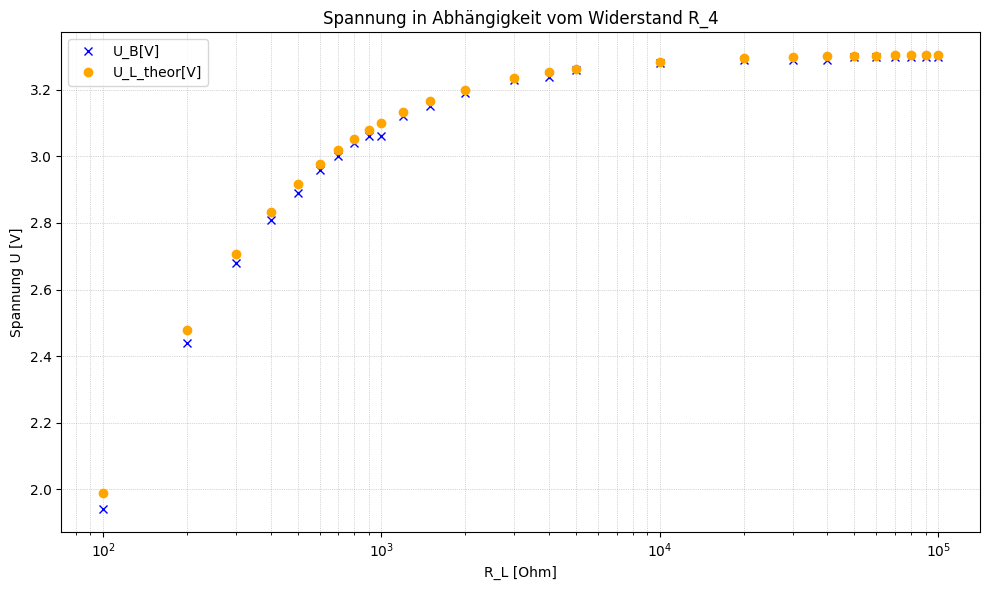

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CSV-Datei laden
df = pd.read_csv('Daten/Daten_Aufgabe_2.csv')
df.columns = ['R_L[Ohm]','U[V]','U_L[V]']

# Konstanten definieren
R_1 = 100
R_2 = 200

def U_L(U, R):
    U_L = U * R_2*R/(R_1*R_2 + R_1*R + R_2*R)
    return U_L

df['U_L_theor'] = U_L(df['U[V]'], df['R_L[Ohm]'])

plt.figure(figsize=(10, 6))
plt.plot(df['R_L[Ohm]'], df['U_L[V]'],'x', label='U_B[V]', color='blue')
plt.plot(df['R_L[Ohm]'], df['U_L_theor'],'o', label='U_L_theor[V]', color='orange')
plt.xscale('log')  # log scale makes early points more visible
plt.xlabel('R_L [Ohm]')
plt.ylabel('Spannung U [V]')
plt.title('Spannung in Abhängigkeit vom Widerstand R_4')
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Herleitung der Theoretischen Werte

Die klassische Formel für den Spannungsteiler lautet wie folgt:
$$U_{2} = U \cdot \frac{R_{2}}{R_{1}+R_{2}}$$

Wobei U die angelegte Spannung ist, $U_{2}$ die Spannung die über den Widerstand $R_{2}$ abfällt und $R_{1}, R_{2}$ die Widerstände sind. In unserem Fall haben wir jedoch nicht den klassischen Spannungsteiler, sondern an der Stelle von $R_{2}$ sind 2 parallel geschaltete Widerstände $R_{2}$ und $R_{L}$. Wir wissen durch das 2. Kirchhoffsche Gesetz, dass die Spannung $U_{2}$ gleich der Spannung $U_{L}$ ist. Außerdem gilt für die beiden parallelen Widerstände:
$$R_{2||L} = \frac{1}{\frac{1}{R_{2}} + \frac{1}{R_{L}}} = \frac{R_{2}R_{L}}{R_{2} + R_{L}}$$
Das können wir in unsere klassische Formel eingeben und bekommen daraus:
$$U_{L} = U_{2} = U \cdot \frac{R_{2||L}}{R_{1} + R_{2||L}} = U \cdot \frac{\frac{R_{2}R_{L}}{R_{2} + R_{L}}}{R_{1} + \frac{R_{2}R_{L}}{R_{2} + R_{L}}} = U \cdot \frac{\frac{R_{2}R_{L}}{R_{2} + R_{L}}}{\frac{R_{1}R_{2} + R_{1}R_{L} + R_{2}R_{L}}{R_{2} + R_{L}}} = U \cdot \frac{R_{2}R_{L}}{R_{1}R_{2} + R_{1}R_{L} + R_{2}R_{L}}$$

In unserem Versuch haben wir für $U = 5 V$ angelegt, welche wir nochmal am Board gemessen haben und kleiner Abweichungen gemessen haben. Für $R_{L} = 100 \Omega$ haben wir $U = 4,97V$ gemessen und bei allen anderen $U=4,96V$. Für die Widerstände haben wir $R_{1} = 100 \Omega$ und $R_{2} = 200 \Omega$ gewählt, also wie vorgegeben $R_{1} < R{2}$. Wir haben $R_{L} = 100 \Omega$ als Startzustand gewählt, da $R_{1||2} = \frac{1}{\frac{1}{100 \Omega} + \frac{1}{200 \Omega}} = \frac{200}{3} \Omega$ und da wir $100 \Omega$ Schritte machen wollten, war $100 \Omega$ der nächstbeste Wert.